# Análisis exploratorio de los datos (EDA)
En este notebook haremos una auditoría exhaustiva del dataset Online Retail. A través de él revisaremos la integridad de los datos y detectaremos posibles anomalías antes de pasar a la limpieza. Para que el análisis sea más visual e intuitivo, apoyaremos las conclusiones con gráficos específicos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [DOC] En este apartado realizamos la carga de los datos y una configuración estética.
df = pd.read_csv('../data/raw/data.csv', encoding='ISO-8859-1')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print(f"[INFO] Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.info())
display(df.describe())

[INFO] Dataset cargado: 541909 filas y 8 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


None

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


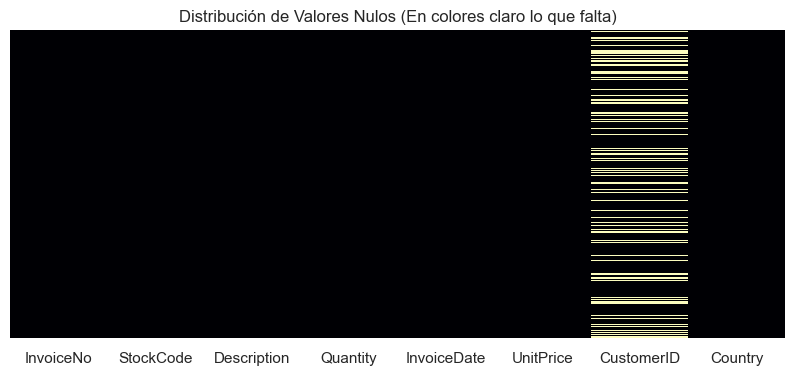


[INFO] Conteo exacto de nulos:
Description      1454
CustomerID     135080
dtype: int64


In [7]:
# [DOC] Procederemos a crear una visualización que nos detecte los datos faltantes. Los colores claros indican la ausencia de datos (nulos).

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Distribución de Valores Nulos (En colores claro lo que falta)')
plt.show()

print("\n[INFO] Conteo exacto de nulos:")
print(df.isnull().sum()[df.isnull().sum() > 0])

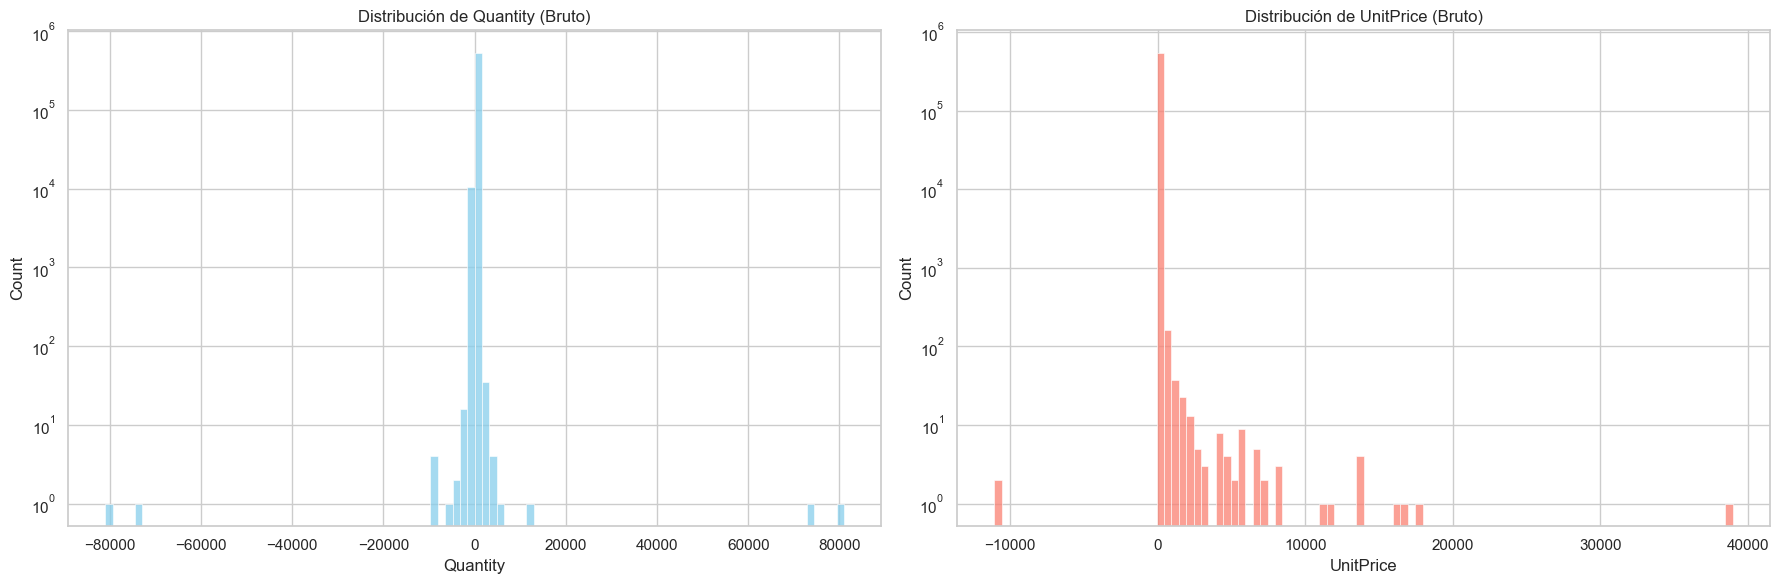

In [4]:
# [DOC] En este aparetado generaremos dos histogramas de las cantidades y del precio unitario.

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# [DOC] Histograma de Cantidades
sns.histplot(df['Quantity'], bins=100, ax=ax[0], color='skyblue', kde=False)
ax[0].set_title('Distribución de Quantity (Bruto)')
ax[0].set_yscale('log')

# [DOC] Histograma de Precios
sns.histplot(df['UnitPrice'], bins=100, ax=ax[1], color='salmon', kde=False)
ax[1].set_title('Distribución de UnitPrice (Bruto)')
ax[1].set_yscale('log')

plt.tight_layout()
plt.show()

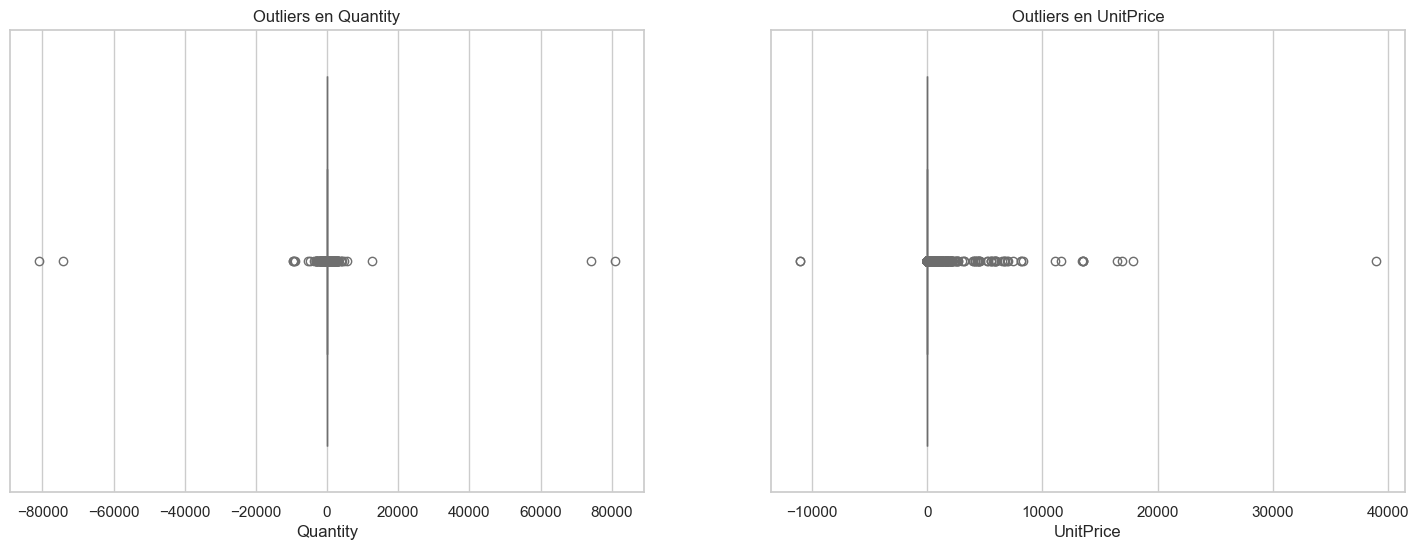

In [5]:
# [DOC] Ahora realizamos creamos dos boxplot para detectar outliers en los campos de cantidades y precio unitario.

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# [DOC] Boxplot Quantity
sns.boxplot(x=df['Quantity'], ax=ax[0], color='skyblue')
ax[0].set_title('Outliers en Quantity')

# [DOC] Boxplot UnitPrice
sns.boxplot(x=df['UnitPrice'], ax=ax[1], color='salmon')
ax[1].set_title('Outliers en UnitPrice')

plt.show()

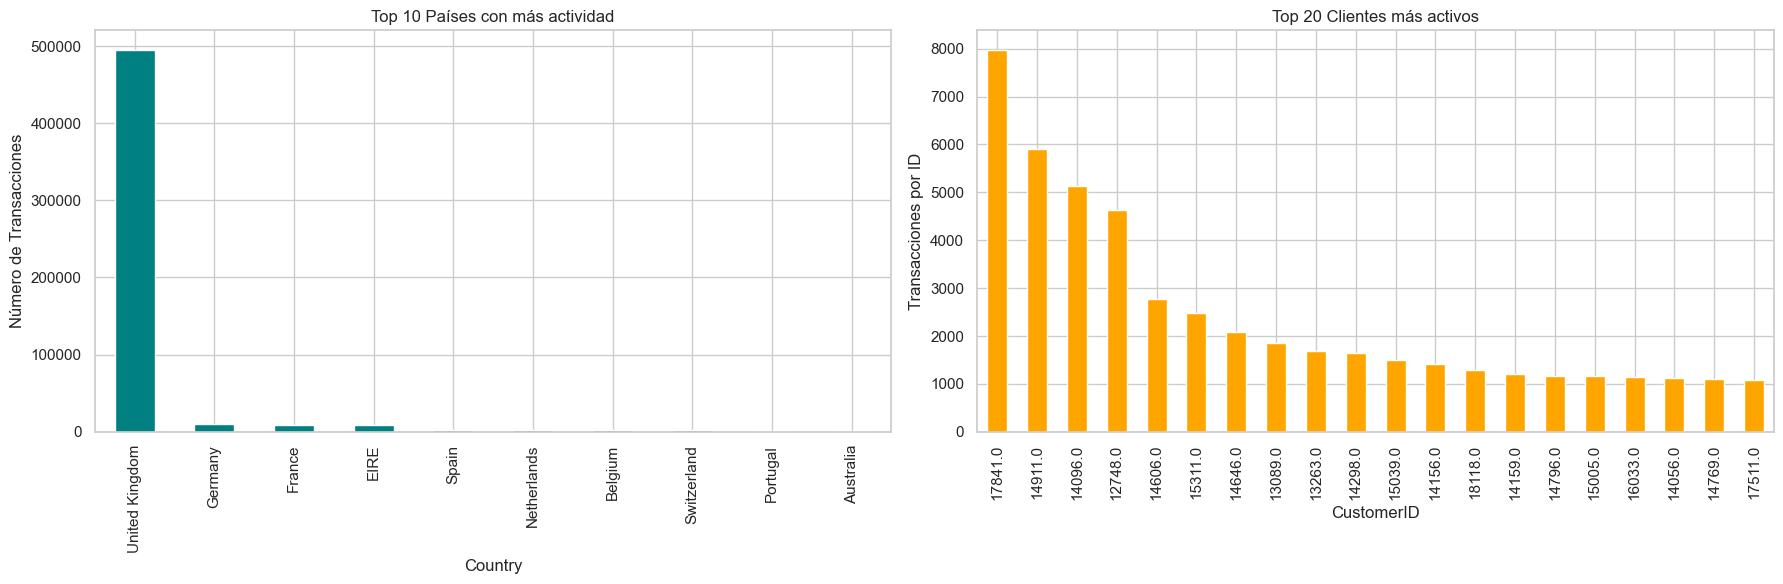

In [6]:
# [DOC] Por un lado hacemos otra gráfica para detectar el top 10 de los países por número de transacciones y por otro lado otra gráfica de top 20 de lcientes por transacciones.

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# [DOC] Top 10 países por transacciones.
df['Country'].value_counts().head(10).plot(kind='bar', ax=ax[0], color='teal')
ax[0].set_title('Top 10 Países con más actividad')
ax[0].set_ylabel('Número de Transacciones')

# [DOC] Top 20 clientes por transacciones.
customer_counts = df['CustomerID'].value_counts().head(20)
customer_counts.plot(kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Top 20 Clientes más activos')
ax[1].set_ylabel('Transacciones por ID')

plt.tight_layout()
plt.show()